In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDSEED = 42
listmodel = {}

In [2]:
train_data = pd.read_csv('train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv('test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].median())
test_data["Age"] = test_data["Age"].fillna(test_data["Age"].median())

In [7]:
train_data["Embarked"] = train_data["Embarked"].fillna(train_data["Embarked"].mode()[0])
test_data["Embarked"] = test_data["Embarked"].fillna(test_data["Embarked"].mode()[0])

In [8]:
train_data["Deck"] = train_data["Cabin"].str[0]
train_data["Deck"] = train_data["Deck"].fillna("Unknown")

In [9]:
train_data["Title"] = train_data["Name"].str.extract(
    r" ([A-Za-z]+)\.",
    expand=False
)
train_data["Title"].unique()

<StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str

In [10]:
train_data["Title"] = train_data["Title"].replace(
    [
        "Lady","Countess","Capt","Col",
        "Don","Dr","Major","Rev",
        "Sir","Jonkheer","Dona"
    ],
    "Rare"
)
train_data["Title"].unique()


<StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Rare', 'Mme', 'Ms', 'Mlle']
Length: 8, dtype: str

In [11]:
train_data["FamilySize"] = (
    train_data["SibSp"] + train_data["Parch"] + 1
)

In [12]:
train_data["IsAlone"] = (
    train_data["FamilySize"] == 1
).astype(int)

In [13]:
train_data["FarePerPerson"] = (
    train_data["Fare"] /
    train_data["FamilySize"]
)

In [14]:
train_data = train_data.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

In [15]:
train_data["Sex"] = train_data["Sex"].map({
    "male": 0,
    "female": 1
})

In [16]:
# Mengubah kolom kategorikal "Embarked" menjadi beberapa kolom biner (One-Hot Encoding)
# Kategori Embarked terdiri dari:
# C = Cherbourg
# Q = Queenstown
# S = Southampton

# drop_first=True digunakan untuk menghapus satu kategori (C) sebagai kategori acuan (baseline).
# Alasannya karena jika ketiga kolom (C, Q, S) disimpan, akan terjadi dummy variable trap
# atau perfect multicollinearity, sebab nilai C selalu bisa dihitung dari Q dan S.
#
# Contoh:
# Q = 0 dan S = 0 -> C
# Q = 1 dan S = 0 -> Q
# Q = 0 dan S = 1 -> S
train_data = pd.get_dummies(
    train_data,
    columns=["Embarked"],
    drop_first=True
)

In [17]:
train_data = pd.get_dummies(
    train_data,
    columns=["Title"],
    drop_first=True
)


In [18]:
train_data = pd.get_dummies(
    train_data,
    columns=["Deck"],
    drop_first=True
)


In [19]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    int64  
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   FamilySize     891 non-null    int64  
 8   IsAlone        891 non-null    int64  
 9   FarePerPerson  891 non-null    float64
 10  Embarked_Q     891 non-null    bool   
 11  Embarked_S     891 non-null    bool   
 12  Title_Miss     891 non-null    bool   
 13  Title_Mlle     891 non-null    bool   
 14  Title_Mme      891 non-null    bool   
 15  Title_Mr       891 non-null    bool   
 16  Title_Mrs      891 non-null    bool   
 17  Title_Ms       891 non-null    bool   
 18  Title_Rare     891 no

In [20]:
corr = train_data.corr(numeric_only=True)
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,Title_Ms,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,False,False,False,False,False,False,False,False,False,True
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,False,False,False,True,False,False,False,False,False,False
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,False,False,False,False,False,False,False,False,False,True
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,False,False,False,True,False,False,False,False,False,False
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,False,False,False,False,False,False,False,False,False,True


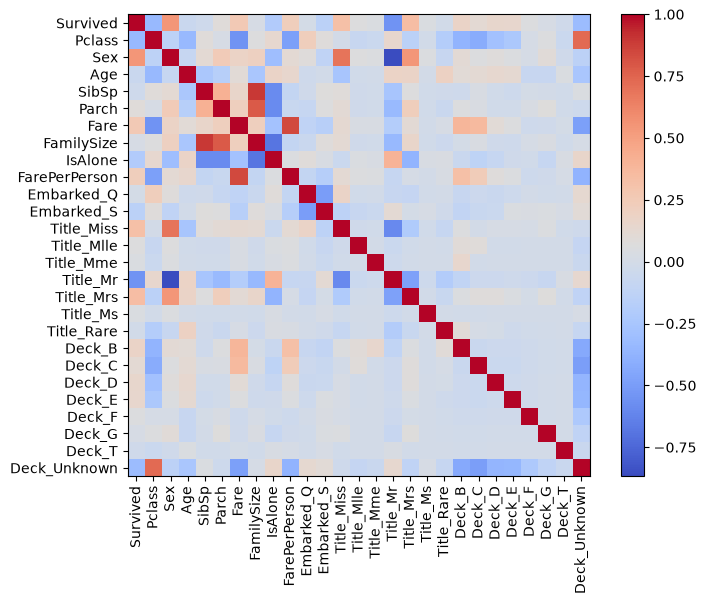

In [21]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [22]:
# pisahkan fitur dan target
X = train_data.drop("Survived", axis=1)
y = train_data["Survived"]

In [23]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDSEED)

In [24]:
def train_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    cv_score = cross_validate(model, X_train, y_train, cv = 5, scoring='accuracy')

    print(f"Model: {model.__class__.__name__}")
    print(f"Train Accuracy: {train_acc}")
    print(f"Test Accuracy: {test_acc}")
    print(f"CV Mean: {cv_score.mean()}")
    print(f"CV Std: {cv_score.std}")
    
    

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# logreg model
model = LogisticRegression(random_state=RANDSEED)
model.fit(X_train_scaled, y_train)

y_pred_logreg = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Accuracy : 0.8212290502793296
[[89 16]
 [16 58]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [27]:
# decision tree model
model = DecisionTreeClassifier(random_state=RANDSEED)
model.fit(X_train, y_train)
y_pred_dt = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7988826815642458
[[86 19]
 [17 57]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       105
           1       0.75      0.77      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [28]:
# random forest model
model = RandomForestClassifier(random_state=RANDSEED)
model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8268156424581006
[[90 15]
 [16 58]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       105
           1       0.79      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [29]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred_knn = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.8044692737430168
[[87 18]
 [17 57]]
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       105
           1       0.76      0.77      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [30]:
model = SVC(random_state=RANDSEED)
model.fit(X_train_scaled, y_train)
y_pred_svm = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8212290502793296
[[88 17]
 [15 59]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [31]:
model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xb = model_xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_xb))
print(confusion_matrix(y_test, y_pred_xb))
print(classification_report(y_test, y_pred_xb))

Accuracy : 0.8324022346368715
[[93 12]
 [18 56]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [32]:
results = pd.DataFrame({
    'Model': [
        'Logistic regression',
        'Decision tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Xgboost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xb)
    ]
})

results

,Model,Accuracy
0,Logistic regression,0.821229
1,Decision tree,0.798883
2,Random Forest,0.826816
3,KNN,0.804469
4,SVM,0.821229
5,Xgboost,0.832402
